In [1]:
import os
import sys 
sys.path.append(os.path.dirname("/Users/aborlaff/NASA/EPHESSOS/ephessos"))
import ephessos as ep

In [2]:
NEA_elements_table = ep.core.read_mpc_nea_file("/Users/aborlaff/NASA/EPHESSOS/notebooks/NEA-test.txt")

i = 0 

from astropy.time import Time
mjd_start = Time('2020-01-01T00:00:00', format='isot', scale='utc').mjd
mjd_end = Time('2026-01-02T00:00:00', format='isot', scale='utc').mjd

#if NEA_elements_table.iloc[i]["Epoch"] == "K25BL":
#    epoch = Time('2025-11-21T00:00:00', format='isot', scale='tt').jd
#    print(epoch)

horizons_dataframe = ep.core.ephessos(epoch=NEA_elements_table.iloc[i]["Epoch"], 
                      eccentricity=NEA_elements_table.iloc[i]["Eccentricity"], 
                      node=NEA_elements_table.iloc[i]["Node"], 
                      arg_perihelion=NEA_elements_table.iloc[i]["Arg_Perihelion"], 
                      inclination=NEA_elements_table.iloc[i]["Inclination"], 
                      mean_anomaly=NEA_elements_table.iloc[i]["Mean_Anomaly"], 
                      semimajor_axis=NEA_elements_table.iloc[i]["Semimajor_Axis"], 
                      mean_motion=NEA_elements_table.iloc[i]["Mean_Motion"], 
                      H_mag=10, G_slope=1, 
                      mjd_start=mjd_start, 
                      mjd_end=mjd_end, 
                      step_size="1d", 
                      verbose=True)

--designation=Default --epoch=K25BL --eccentricity=0.222836 --node=304.27008, --arg_perihelion=178.92978 --inclination=10.82847 --mean_anomaly=310.55432 --semimajor_axis=1.458121 --mean_motion=0.55977529 --mjd_start=58849.0 --mjd_end=61042.0 --step_size=1d
https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND=';'&EPOCH=2461000.5&ECLIP=J2000&EC=0.222836&OM=304.27008&W=178.92978&IN=10.82847&MA=310.55432&A=1.458121&H=10&G=1&OBJ_DATA='YES'&MAKE_EPHEM='YES'&EPHEM_TYPE='OBSERVER'&CENTER='500@32'&START_TIME='2020-01-01T00:00:00.000'&STOP_TIME='2026-01-02T00:00:00.000'&STEP_SIZE='1d'&CSV_FORMAT='YES'&QUANTITIES='1,2,3,4,5,6,7,8,9,10,19,20,23,24,25,27,29'
['2020-01-01 00:00' '2020-01-02 00:00' '2020-01-03 00:00' ...
 '2025-12-31 00:00' '2026-01-01 00:00' '2026-01-02 00:00']


In [10]:
eros_horizons_dataframe = ep.core.ephessos(designation="00433", epoch="K25BL",
                      mjd_start=mjd_start, 
                      mjd_end=mjd_end, 
                      step_size="1d", 
                      verbose=True)

print(eros_horizons_dataframe)

--designation=00433 --epoch=K25BL --eccentricity=None --node=None, --arg_perihelion=None --inclination=None --mean_anomaly=None --semimajor_axis=None --mean_motion=None --mjd_start=58849.0 --mjd_end=61042.0 --step_size=1d
https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND='00433'&EPOCH=2461000.5&ECLIP=J2000&OBJ_DATA='YES'&MAKE_EPHEM='YES'&EPHEM_TYPE='OBSERVER'&CENTER='500@32'&START_TIME='2020-01-01T00:00:00.000'&STOP_TIME='2026-01-02T00:00:00.000'&STEP_SIZE='1d'&CSV_FORMAT='YES'&QUANTITIES='1,2,3,4,5,6,7,8,9,10,19,20,23,24,25,27,29'
['2020-01-01 00:00' '2020-01-02 00:00' '2020-01-03 00:00' ...
 '2025-12-31 00:00' '2026-01-01 00:00' '2026-01-02 00:00']
       Date__(UT)__HR:MN         R.A._(ICRF)   DEC__(ICRF)    R.A.__(a-app)  \
0      2020-Jan-01 00:00         19 58 12.29   -20 15 59.4      19 58 10.89   
1      2020-Jan-02 00:00         20 00 37.76   -20 06 21.7      20 00 36.36   
2      2020-Jan-03 00:00         20 03 03.00   -19 56 36.6      20 03 01.60   
3      2020-J

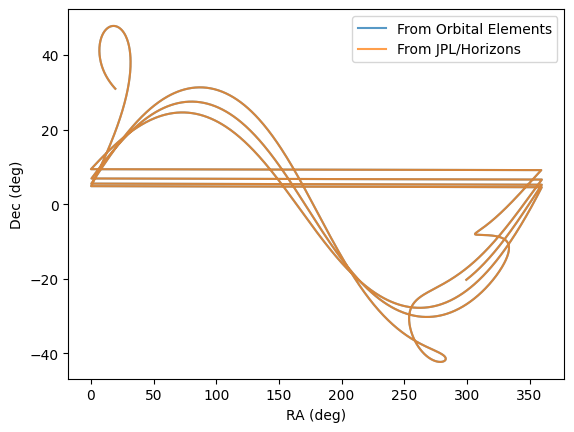

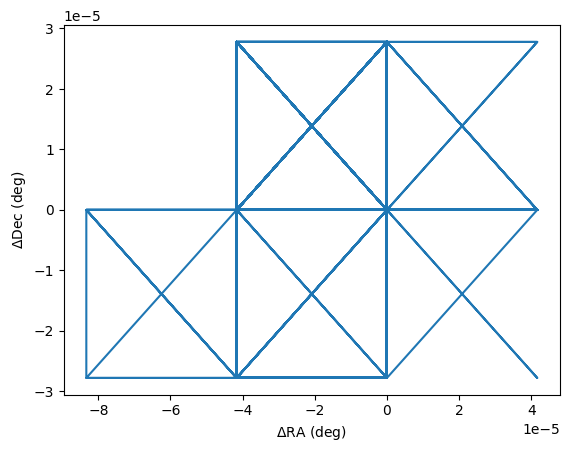

In [11]:
import matplotlib.pyplot as plt
plt.plot(horizons_dataframe["RA_deg_ICRF"], horizons_dataframe["DEC_deg_ICRF"], alpha=0.75, label="From Orbital Elements")
plt.plot(eros_horizons_dataframe["RA_deg_ICRF"], eros_horizons_dataframe["DEC_deg_ICRF"], alpha=0.75, label="From JPL/Horizons")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.legend() 
plt.savefig("horizons_vs_elements_comparison.png", dpi=300)
plt.show()


plt.plot(horizons_dataframe["RA_deg_ICRF"] - eros_horizons_dataframe["RA_deg_ICRF"], horizons_dataframe["DEC_deg_ICRF"] - eros_horizons_dataframe["DEC_deg_ICRF"])
plt.xlabel(r'$\Delta$RA (deg)')
plt.ylabel(r'$\Delta$Dec (deg)') 
plt.savefig("horizons_vs_elements_comparison_delta.png", dpi=300)
plt.show()
